### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [2]:
import tensorflow as tf
tf.set_random_seed(42)

/opt/conda/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters


In [3]:
tf.__version__

'1.14.0'

### Collect Data

In [4]:
import keras

Using TensorFlow backend.


In [5]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

4423680/4422102 [==============================] - 0s 0us/step


In [6]:
print(testY[0:5])

[9 2 1 1 6]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [7]:
from keras.utils import np_utils
import numpy as np

In [8]:
Y_train=np_utils.to_categorical(trainY,10)
Y_test=np_utils.to_categorical(testY,10)

In [9]:
Y_train[3]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [10]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000,)
First 5 examples now are:  [9 0 0 3 0]


In [11]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Visualize the data

Plot first 10 images in the triaining set and their labels.

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

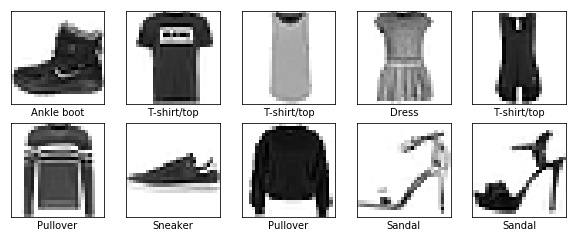

In [13]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[trainY[i]])
plt.show()

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [14]:
x_train=trainX.reshape(trainX.shape[0],28,28,1).astype('float32')
x_test=testX.reshape(testX.shape[0],28,28,1).astype('float32')

In [15]:
x_train/=255
x_test/=255

In [16]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.utils import np_utils
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

W0728 16:00:59.885972 140397291521792 deprecation_wrapper.py:119] From /opt/conda/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  
W0728 16:00:59.888239 140397291521792 deprecation_wrapper.py:119] From /opt/conda/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0728 16:00:59.891713 140397291521792 deprecation_wrapper.py:119] From /opt/conda/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0728 16:00:59.905620 140397291521792 deprecation_wrapper.py:119] From /op

### Execute the model using model.fit()

In [19]:
model.fit(x_train,Y_train,batch_size=200,nb_epoch=12,verbose=1,validation_data=(x_test,Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/12
  800/60000 [..............................] - ETA: 13s - loss: 0.4188 - acc: 0.8488

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


60000/60000 [==============================] - 10s 173us/step - loss: 0.4243 - acc: 0.8509 - val_loss: 0.4586 - val_acc: 0.8381
Epoch 2/12
60000/60000 [==============================] - 10s 174us/step - loss: 0.4122 - acc: 0.8558 - val_loss: 0.4423 - val_acc: 0.8448
Epoch 3/12
60000/60000 [==============================] - 11s 178us/step - loss: 0.4075 - acc: 0.8584 - val_loss: 0.4950 - val_acc: 0.8231
Epoch 4/12
60000/60000 [==============================] - 10s 174us/step - loss: 0.4015 - acc: 0.8593 - val_loss: 0.4364 - val_acc: 0.8430
Epoch 5/12
60000/60000 [==============================] - 11s 178us/step - loss: 0.3991 - acc: 0.8600 - val_loss: 0.4163 - val_acc: 0.8537
Epoch 6/12
60000/60000 [==============================] - 10s 170us/step - loss: 0.3929 - acc: 0.8625 - val_loss: 0.4138 - val_acc: 0.8561
Epoch 7/12
60000/60000 [==============================] - 10s 173us/step - loss: 0.3869 - acc: 0.8640 - val_loss: 0.4024 - val_acc: 0.8587
Epoch 8/12
60000/60000 [==============

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [20]:
from keras.layers.normalization import BatchNormalization

In [21]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(10,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


### Execute the model

In [22]:
model.fit(x_train,Y_train,batch_size=200,nb_epoch=12,verbose=1,validation_data=(x_test,Y_test))

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 10s 170us/step - loss: 0.5428 - acc: 0.8172 - val_loss: 0.4711 - val_acc: 0.8362
Epoch 2/12
60000/60000 [==============================] - 10s 162us/step - loss: 0.3901 - acc: 0.8664 - val_loss: 0.3927 - val_acc: 0.8641
Epoch 3/12
60000/60000 [==============================] - 10s 167us/step - loss: 0.3461 - acc: 0.8799 - val_loss: 0.3859 - val_acc: 0.8590
Epoch 4/12
60000/60000 [==============================] - 10s 168us/step - loss: 0.3185 - acc: 0.8900 - val_loss: 0.3400 - val_acc: 0.8799
Epoch 5/12
60000/60000 [==============================] - 10s 167us/step - loss: 0.2994 - acc: 0.8972 - val_loss: 0.3380 - val_acc: 0.8828
Epoch 6/12
60000/60000 [==============================] - 10s 165us/step - loss: 0.2829 - acc: 0.9018 - val_loss: 0.3312 - val_acc: 0.8813
Epoch 7/12
60000/60000 [==============================] - 10s 169us/step - loss: 0.2697 - acc: 0.9066 - val_loss: 0.

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [23]:
from keras import optimizers


In [24]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(10,activation='softmax'))
sgd = optimizers.SGD(lr=0.001, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


In [25]:
model.fit(x_train,Y_train,batch_size=200,nb_epoch=12,verbose=1,validation_data=(x_test,Y_test))

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 10s 171us/step - loss: 0.5382 - acc: 0.8183 - val_loss: 0.4492 - val_acc: 0.8479
Epoch 2/12
60000/60000 [==============================] - 10s 163us/step - loss: 0.3921 - acc: 0.8663 - val_loss: 0.4035 - val_acc: 0.8612
Epoch 3/12
60000/60000 [==============================] - 11s 177us/step - loss: 0.3520 - acc: 0.8790 - val_loss: 0.3730 - val_acc: 0.8687
Epoch 4/12
60000/60000 [==============================] - 10s 165us/step - loss: 0.3265 - acc: 0.8871 - val_loss: 0.3568 - val_acc: 0.8745
Epoch 5/12
60000/60000 [==============================] - 10s 165us/step - loss: 0.3077 - acc: 0.8933 - val_loss: 0.3510 - val_acc: 0.8745
Epoch 6/12
60000/60000 [==============================] - 10s 166us/step - loss: 0.2908 - acc: 0.8990 - val_loss: 0.3473 - val_acc: 0.8766
Epoch 7/12
60000/60000 [==============================] - 10s 167us/step - loss: 0.2789 - acc: 0.9032 - val_loss: 0.

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [26]:
model=Sequential()
model.add(Conv2D(32,(3,3),border_mode='valid',input_shape=(28,28,1),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(100,activation='sigmoid'))
model.add(Dense(100,activation='sigmoid'))
model.add(BatchNormalization())
model.add(Dense(10,activation='softmax'))
sgd = optimizers.SGD(lr=0.03, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy',optimizer='sgd',metrics=['accuracy'])

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), input_shape=(28, 28, 1..., activation="relu", padding="valid")`
  


In [27]:
model.fit(x_train,Y_train,batch_size=200,nb_epoch=12,verbose=1,validation_data=(x_test,Y_test))

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 60000 samples, validate on 10000 samples
Epoch 1/12
60000/60000 [==============================] - 11s 181us/step - loss: 0.8873 - acc: 0.7117 - val_loss: 0.6684 - val_acc: 0.7574
Epoch 2/12
60000/60000 [==============================] - 10s 167us/step - loss: 0.5794 - acc: 0.8006 - val_loss: 0.5587 - val_acc: 0.8032
Epoch 3/12
60000/60000 [==============================] - 10s 175us/step - loss: 0.5160 - acc: 0.8211 - val_loss: 0.5217 - val_acc: 0.8176
Epoch 4/12
60000/60000 [==============================] - 10s 167us/step - loss: 0.4816 - acc: 0.8344 - val_loss: 0.4970 - val_acc: 0.8268
Epoch 5/12
60000/60000 [==============================] - 10s 170us/step - loss: 0.4568 - acc: 0.8432 - val_loss: 0.4753 - val_acc: 0.8340
Epoch 6/12
60000/60000 [==============================] - 10s 170us/step - loss: 0.4376 - acc: 0.8493 - val_loss: 0.4638 - val_acc: 0.8365
Epoch 7/12
60000/60000 [==============================] - 10s 173us/step - loss: 0.4219 - acc: 0.8545 - val_loss: 0.

## Review model

In [28]:
score=model.evaluate(x_test,Y_test)

10000/10000 [==============================] - 1s 76us/step


In [29]:
score

[0.38938169593811034, 0.865]

### Run the model

In [30]:
y_predict = model.predict(x_test)
np.argmax(y_predict[0])

9

In [34]:
testY

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [35]:
y_pred = []
for val in y_predict:
    y_pred.append(np.argmax(val))
#print(y_pred)    
#convert 0 1 to 1 and 1 0 as 0
cm = metrics.confusion_matrix(testY,y_pred)
print(cm)

[[892   0  13  28   7   1  46   0  12   1]
 [  4 960   3  25   3   0   3   0   2   0]
 [ 20   2 795  11 100   1  65   1   5   0]
 [ 43  18   8 851  35   0  40   0   4   1]
 [  0   1  78  32 818   0  66   0   5   0]
 [  0   0   0   1   0 947   0  36   1  15]
 [192   2  91  24 104   1 564   0  22   0]
 [  0   0   0   0   0  40   0 895   1  64]
 [  5   1   1   9   4   4   9   6 961   0]
 [  0   0   0   0   0   8   0  24   1 967]]


In [36]:
cr=metrics.classification_report(testY,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.77      0.89      0.83      1000
           1       0.98      0.96      0.97      1000
           2       0.80      0.80      0.80      1000
           3       0.87      0.85      0.86      1000
           4       0.76      0.82      0.79      1000
           5       0.95      0.95      0.95      1000
           6       0.71      0.56      0.63      1000
           7       0.93      0.90      0.91      1000
           8       0.95      0.96      0.95      1000
           9       0.92      0.97      0.94      1000

   micro avg       0.86      0.86      0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

